# Tech Challenge F4 — EDA (Exploratory Data Analysis)

> Notebook acadêmico para análise exploratória da série AMZN (Yahoo Finance).

**Objetivos:**
- Inspecionar e entender os dados brutos (OHLCV).
- Checar qualidade dos dados: datas, faltantes, duplicados, timezone.
- Explorar propriedades estatísticas: retornos, volatilidade, ACF/PACF, estacionariedade (ADF).
- Visualizar decomposição sazonal simples.
- Sugerir split temporal (70/15/15) e visualizar cortes.
- Salvar um *resumo* (JSON) com métricas básicas de EDA.

**Obs.**: Este notebook tenta usar um CSV bruto em `data/raw/`. Se não encontrar, baixa via `yfinance`.

In [1]:
# Imports principais (mantidos simples e com comentários sucintos)
from __future__ import annotations

import os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

# IMPORTANTE: como estamos rodando a partir da pasta notebooks/, ROOT deve ser ..
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'notebooks' / 'outputs'
for p in (DATA_RAW, DATA_PROCESSED, OUTPUTS):
    p.mkdir(parents=True, exist_ok=True)

TICKER = os.getenv('TICKER', 'AMZN')
START = os.getenv('START', '2018-01-01')
END = os.getenv('END', None)  # se None, yfinance usa 'hoje'
print(f'Usando TICKER={TICKER}, START={START}, END={END}')

Usando TICKER=AMZN, START=2018-01-01, END=None


## Funções utilitárias

In [3]:
def _latest_raw_csv(ticker: str) -> Path | None:
    """Devolve o caminho do CSV bruto mais recente em data/raw para o ticker.
    Espera arquivos no padrão `<TICKER>_YYYY-MM-DD_YYYY-MM-DD.csv`.
    """
    if not DATA_RAW.exists():
        return None
    cands = sorted([p for p in DATA_RAW.glob(f'{ticker}_*.csv')])
    return cands[-1] if cands else None

def _clean_index(df: pd.DataFrame) -> pd.DataFrame:
    """Garante índice datetime sem timezone, ordenado e sem duplicatas."""
    if 'Date' in df.columns:
        df = df.rename(columns={'Date': 'Datetime'})
    if 'Datetime' in df.columns:
        idx = pd.to_datetime(df['Datetime'], errors='coerce')
        df = df.drop(columns=['Datetime'])
        df.index = idx
    elif not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')
    # Remove timezone se houver e ordena
    if getattr(df.index, 'tz', None) is not None:
        df.index = df.index.tz_localize(None)
    df = df[~df.index.duplicated(keep='last')].sort_index()
    return df

def flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Achata colunas MultiIndex em strings simples.
    Ex.: ('Price','Close')->'Price_Close', ('Close','AMZN')->'Close_AMZN'.
    Se já for Index simples, não faz nada.
    """
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = ['_'.join([str(x) for x in tup if x is not None]).strip()
                      for tup in df.columns.to_list()]
    return df

def _download_yf(ticker: str, start: str, end: str | None = None) -> pd.DataFrame:
    """Baixa via yfinance e retorna DataFrame com colunas OHLCV."""
    print('Baixando via yfinance...')
    # group_by='column' ajuda a evitar MultiIndex por ticker
    df = yf.download(ticker, start=start, end=end, interval='1d',
                     auto_adjust=True, group_by='column')
    if df is None or df.empty:
        raise RuntimeError('yfinance retornou DataFrame vazio.')
    df = flatten_columns(df)
    # Renomeia apenas se as colunas clássicas existem
    ren = {'Open': 'Open', 'High': 'High', 'Low': 'Low',
           'Close': 'Close', 'Adj Close': 'Adj Close', 'Volume': 'Volume'}
    df = df.rename(columns={k: v for k, v in ren.items() if k in df.columns})
    return df

## Carregamento de dados

In [4]:
raw_csv = _latest_raw_csv(TICKER)
if raw_csv:
    print(f'Carregando CSV bruto: {raw_csv}')
    df = pd.read_csv(raw_csv)
else:
    df = _download_yf(TICKER, START, END)
    # persiste para reprodutibilidade
    start_str = df.index.min().strftime('%Y-%m-%d') if isinstance(df.index, pd.DatetimeIndex) else str(df.index.min())
    end_str = df.index.max().strftime('%Y-%m-%d') if isinstance(df.index, pd.DatetimeIndex) else str(df.index.max())
    save_path = DATA_RAW / f'{TICKER}_{start_str}_{end_str}.csv'
    df.to_csv(save_path)
    print(f'Dados salvos em: {save_path}')

df = _clean_index(df)
df = flatten_columns(df)  # evita chaves-tuple em dicionários
display(df.head())
display(df.tail())
print('Shape:', df.shape)
print('Colunas:', list(df.columns))
print('Período:', df.index.min().date(), '→', df.index.max().date())

Carregando CSV bruto: ../data/raw/AMZN_2018-01-02_2025-12-05.csv


,Open,High,Low,Close,Volume
Datetime,,,,,
2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000
2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000
2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000
2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000
2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000


,Open,High,Low,Close,Volume
Datetime,,,,,
2025-12-01,233.220001,235.800003,232.250000,233.880005,42904000
2025-12-02,235.009995,238.970001,233.550003,234.419998,45785400
2025-12-03,233.350006,233.380005,230.610001,232.380005,35495100
2025-12-04,232.770004,233.500000,226.800003,229.110001,45683200
2025-12-05,230.320007,231.240005,228.550003,229.529999,33075500


Shape: (1994, 5)
Colunas: ['Open', 'High', 'Low', 'Close', 'Volume']
Período: 2018-01-02 → 2025-12-05


## Qualidade dos dados: faltantes e sumário

In [5]:
na_counts = df.isna().sum()
display(na_counts.to_frame('missing'))
display(df.describe(include='all').T)

,missing
Open,0
High,0
Low,0
Close,0
Volume,0


,count,mean,std,min,25%,50%,75%,max
Open,1994.0,1.395893e+02,4.655883e+01,5.860000e+01,9.432912e+01,1.400750e+02,1.728722e+02,2.553600e+02
High,1994.0,1.412086e+02,4.694937e+01,5.950000e+01,9.547613e+01,1.422442e+02,1.746256e+02,2.586000e+02
Low,1994.0,1.378082e+02,4.606261e+01,5.852550e+01,9.330062e+01,1.378300e+02,1.710275e+02,2.529000e+02
Close,1994.0,1.395422e+02,4.649169e+01,5.945050e+01,9.436738e+01,1.394650e+02,1.725360e+02,2.540000e+02
Volume,1994.0,7.050104e+07,3.275765e+07,1.500750e+07,4.591075e+07,6.206300e+07,8.762900e+07,1.502064e+08


## Série de preços (Close)

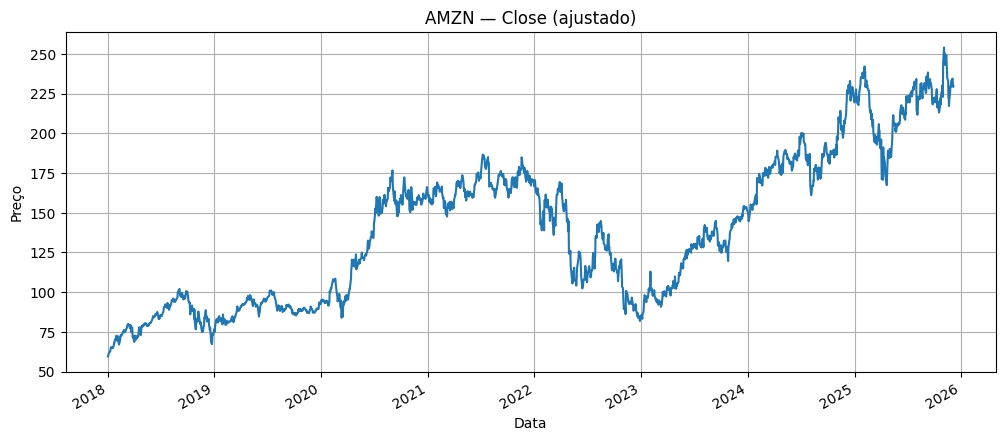

In [6]:
ax = df['Close'].plot(title=f'{TICKER} — Close (ajustado)')
ax.set_xlabel('Data'); ax.set_ylabel('Preço')
plt.show()

## Retornos (simples e log) e volatilidade (rolling)

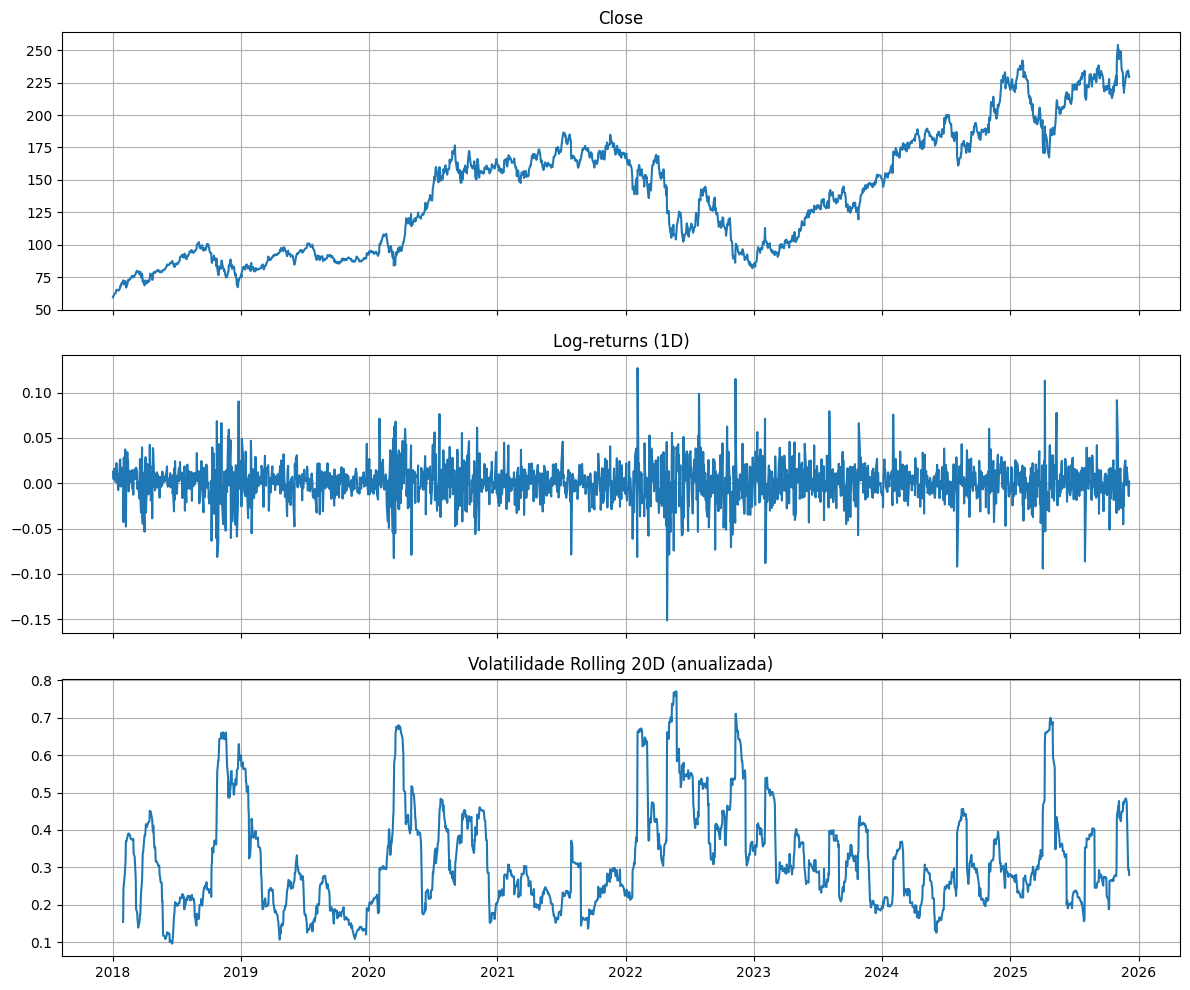

          count      mean       std       min       25%       50%       75%  \
ret1     1993.0  0.000914  0.021744 -0.140494 -0.010353  0.001144  0.012266   
logret1  1993.0  0.000678  0.021733 -0.151398 -0.010407  0.001143  0.012191   
vol20    1974.0  0.320389  0.134358  0.096367  0.220212  0.289559  0.395536   

              max  
ret1     0.135359  
logret1  0.126949  
vol20    0.770341  


In [7]:
df['ret1'] = df['Close'].pct_change()
df['logret1'] = np.log(df['Close']).diff()
df['vol20'] = df['logret1'].rolling(20).std() * np.sqrt(252)  # anualizada aprox.

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axs[0].plot(df.index, df['Close']); axs[0].set_title('Close')
axs[1].plot(df.index, df['logret1']); axs[1].set_title('Log-returns (1D)')
axs[2].plot(df.index, df['vol20']); axs[2].set_title('Volatilidade Rolling 20D (anualizada)')
for ax in axs: ax.grid(True)
plt.tight_layout(); plt.show()

print(df[['ret1','logret1','vol20']].describe().T)

## ACF/PACF dos retornos (indicativos de autocorrelação)

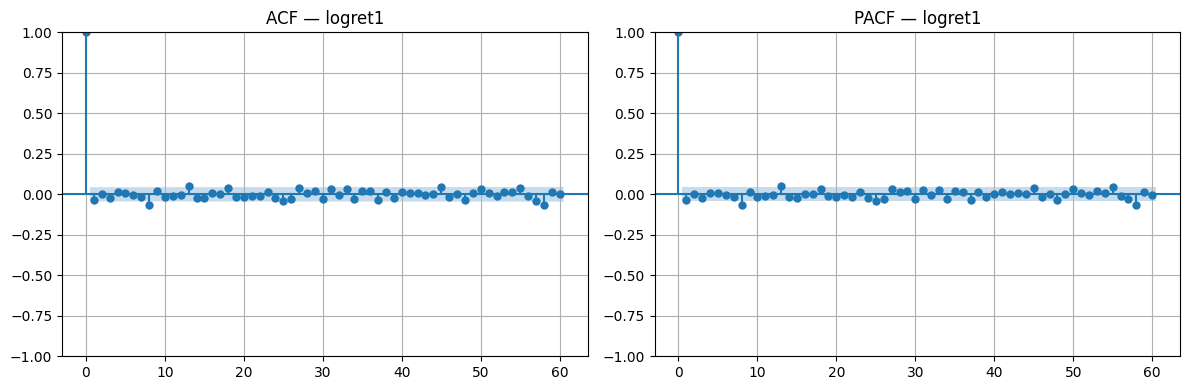

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df['logret1'].dropna(), lags=60, ax=ax[0])
plot_pacf(df['logret1'].dropna(), lags=60, ax=ax[1], method='ywm')
ax[0].set_title('ACF — logret1'); ax[1].set_title('PACF — logret1')
plt.tight_layout(); plt.show()

## Teste de estacionariedade (ADF) — preço vs. retornos

In [9]:
def _adf_summary(x: pd.Series) -> dict:
    x = x.dropna()
    stat, p, lags, nobs, crit, icbest = adfuller(x.values, autolag='AIC')
    return {'stat': float(stat), 'pvalue': float(p), 'lags': int(lags), 'nobs': int(nobs), 'crit': crit}

adf_price = _adf_summary(df['Close'])
adf_ret = _adf_summary(df['logret1'])
print('ADF — Close  :', json.dumps(adf_price, indent=2))
print('ADF — logret1:', json.dumps(adf_ret, indent=2))

ADF — Close  : {
  "stat": -1.3341983001951658,
  "pvalue": 0.6133850019252143,
  "lags": 0,
  "nobs": 1993,
  "crit": {
    "1%": -3.43363537003345,
    "5%": -2.862991296796771,
    "10%": -2.5675426088474738
  }
}
ADF — logret1: {
  "stat": -46.20266997226384,
  "pvalue": 0.0,
  "lags": 0,
  "nobs": 1992,
  "crit": {
    "1%": -3.4336370214482437,
    "5%": -2.862992025899885,
    "10%": -2.5675429970585153
  }
}


## Decomposição sazonal (aditiva) em janela curta (p=30)

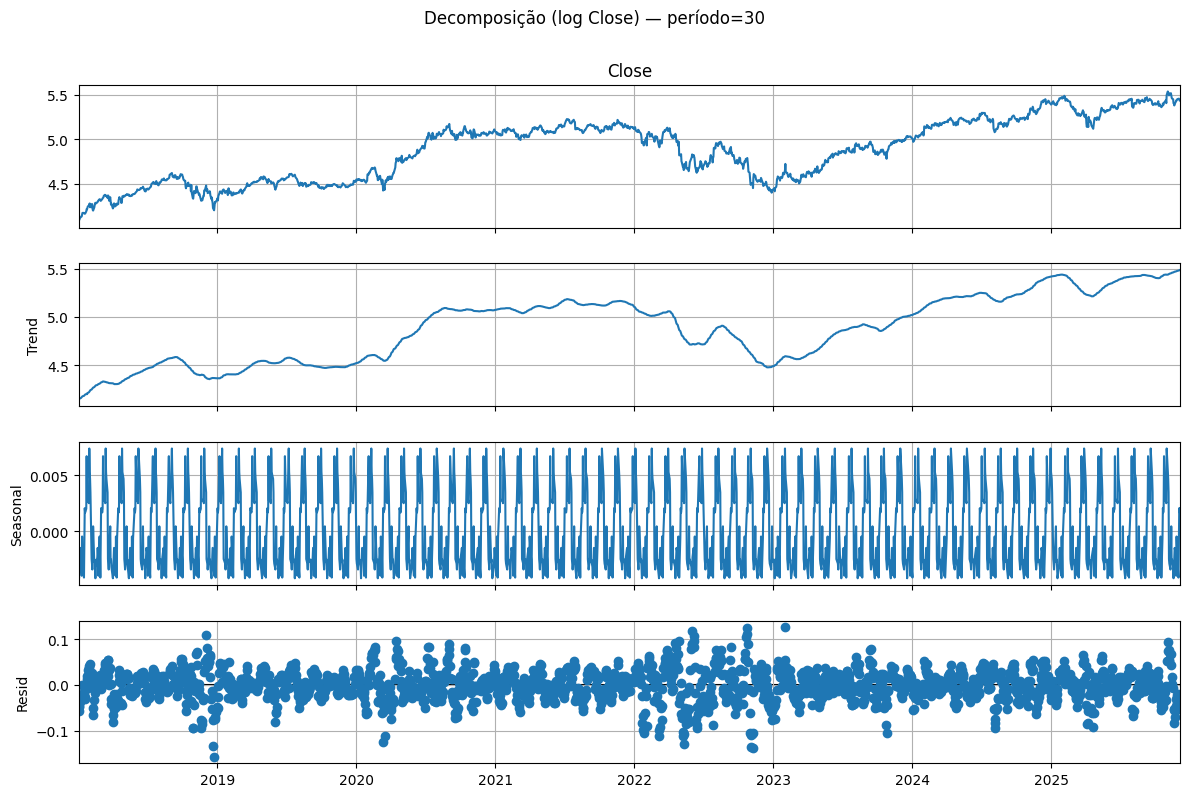

In [10]:
series = np.log(df['Close']).dropna()
decomp = seasonal_decompose(series, model='additive', period=30, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Decomposição (log Close) — período=30', y=1.02)
plt.show()

## Correlação entre variáveis derivadas (OHLCV + retornos/vol)

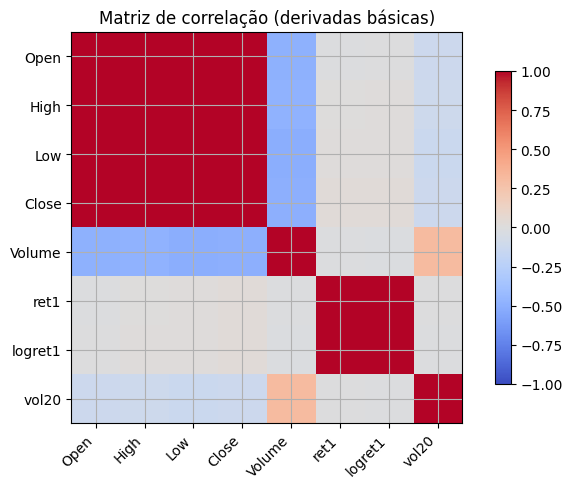

,Open,High,Low,Close,Volume,ret1,logret1,vol20
Open,1.000000,0.999408,0.999360,0.998663,-0.491551,-0.008653,-0.007140,-0.119136
High,0.999408,1.000000,0.999218,0.999397,-0.483905,0.007711,0.008975,-0.110648
Low,0.999360,0.999218,1.000000,0.999416,-0.501576,0.010573,0.012343,-0.127492
Close,0.998663,0.999397,0.999416,1.000000,-0.493150,0.027486,0.029008,-0.118789
Volume,-0.491551,-0.483905,-0.501576,-0.493150,1.000000,-0.011536,-0.022430,0.311182
ret1,-0.008653,0.007711,0.010573,0.027486,-0.011536,1.000000,0.999634,-0.002707
logret1,-0.007140,0.008975,0.012343,0.029008,-0.022430,0.999634,1.000000,-0.011089
vol20,-0.119136,-0.110648,-0.127492,-0.118789,0.311182,-0.002707,-0.011089,1.000000


In [11]:
corr_cols = ['Open','High','Low','Close','Volume','ret1','logret1','vol20']
corr_df = df[corr_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlação (derivadas básicas)')
plt.tight_layout(); plt.show()
corr_df

## Split temporal sugerido (70/15/15) e visualização dos cortes

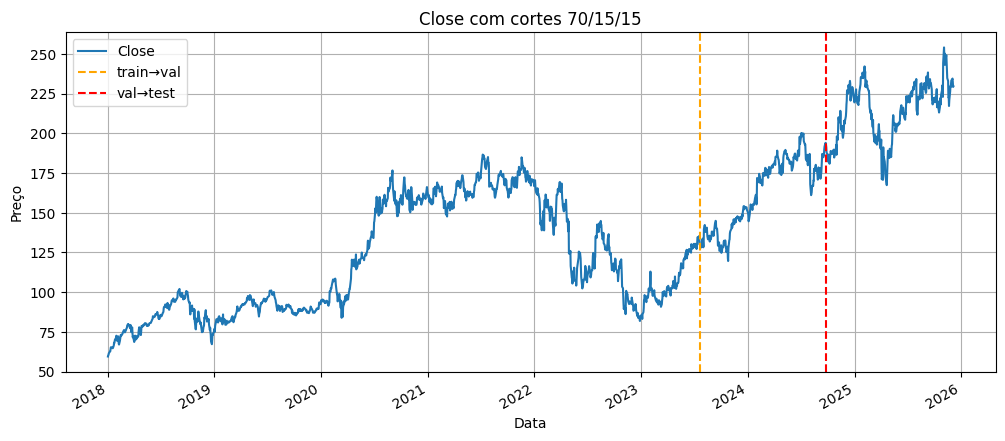

Datas corte: train→val = 2023-07-20 00:00:00 | val→test = 2024-09-26 00:00:00


In [12]:
n = len(df)
i_tr = int(n * 0.70)
i_va = int(n * 0.85)
d_tr_end = df.index[i_tr] if n else None
d_va_end = df.index[i_va] if n else None
ax = df['Close'].plot(title='Close com cortes 70/15/15')
if d_tr_end is not None: ax.axvline(d_tr_end, color='orange', linestyle='--', label='train→val')
if d_va_end is not None: ax.axvline(d_va_end, color='red', linestyle='--', label='val→test')
ax.legend(); ax.set_xlabel('Data'); ax.set_ylabel('Preço'); plt.show()
print('Datas corte:', 'train→val =', d_tr_end, '| val→test =', d_va_end)

## Salvar resumo da EDA em JSON (para reuso na documentação)

In [13]:
summary = {
    'ticker': TICKER,
    'period': [str(df.index.min().date()), str(df.index.max().date())],
    'shape': list(df.shape),
    'missing': {str(k): int(v) for k, v in df.isna().sum().to_dict().items()},
    'adf_close_pvalue': float(adfuller(df['Close'].dropna(), autolag='AIC')[1]),
    'adf_logret1_pvalue': float(adfuller(df['logret1'].dropna(), autolag='AIC')[1])
}
out_path = OUTPUTS / f'eda_summary_{TICKER}.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Resumo salvo em:', out_path)
summary

Resumo salvo em: ../notebooks/outputs/eda_summary_AMZN.json


{'ticker': 'AMZN',
 'period': ['2018-01-02', '2025-12-05'],
 'shape': [1994, 8],
 'missing': {'Open': 0,
  'High': 0,
  'Low': 0,
  'Close': 0,
  'Volume': 0,
  'ret1': 1,
  'logret1': 1,
  'vol20': 20},
 'adf_close_pvalue': 0.6133850019252143,
 'adf_logret1_pvalue': 0.0}

---
**Notas:**
- ADF com *p-value* baixo (tipicamente < 0.05) sugere estacionariedade. Em preços costuma ser alto; em retornos, baixo.
- A decomposição sazonal é apenas ilustrativa (período curto=30).
- Os cortes 70/15/15 aqui são apenas visualização; o pipeline oficial usa as mesmas proporções no `src/data.py`.